Усі імпорти рекомендую розташувати отут зверху для зручності.

In [1]:
import pandas as pd

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


1.Завантажте дані у pandas dataframe з файла `ecommerce_data.csv`. Обовʼязково при завантаженні вкажіть параметр `encoding = 'ISO-8859-1'`, без нього буде помилка.

In [41]:
file_path = '/content/drive/MyDrive/python_labs/optional/ecommerce_data_1.csv'

df = pd.read_csv(file_path, encoding='ISO-8859-1')

2.Виведіть перші три записи в завантаженому наборі даних

In [42]:
df.head(3)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom


3.Перейменуйте колонки, для цього просто запустіть код нижче та зверніть увагу, як ми перейменували колонки. Перейменування тут - просто для зручності.

In [43]:
df.columns = df.columns.str.replace(" ", "_").str.lower()

4.Виведіть поточні назви колонок.

In [44]:
df.columns

Index(['invoiceno', 'stockcode', 'description', 'quantity', 'invoicedate',
       'unitprice', 'customerid', 'country'],
      dtype='object')

# Базове розуміння даних

5.Виведіть кількість колонок і стовпців в наборі даних.

In [45]:
num_rows, num_columns = df.shape

print(f"Кількість рядків: {num_rows}")
print(f"Кількість колонок: {num_columns}")

Кількість рядків: 541909
Кількість колонок: 8


6.Виведіть типи даних в кожній з колонок. Будь-яким способом, але аби для Вас як для дослідника стало зрозуміло, з якими даними ми зараз маємо справу.

In [46]:
df.dtypes

invoiceno       object
stockcode       object
description     object
quantity         int64
invoicedate     object
unitprice      float64
customerid     float64
country         object
dtype: object

Очікуваний результат (один з):

![image.png](attachment:image.png)

7.Виведіть кількість пустих (null) значень в кожній з колонок за спаданням цієї кількості.

In [47]:
null_counts = df.isnull().sum().sort_values(ascending=False)

null_counts

customerid     135080
description      1454
invoiceno           0
stockcode           0
quantity            0
invoicedate         0
unitprice           0
country             0
dtype: int64

Очікуваний результат:

![image.png](attachment:image.png)

### Конвертація дат

8.Конвертуйте дату колонки `invoicedate` у тип `datetime64[ns]`.

In [48]:
df['invoicedate'] = pd.to_datetime(df['invoicedate'])

print(df['invoicedate'].dtypes)
print(df['invoicedate'].head())

datetime64[ns]
0   2010-12-01 08:26:00
1   2010-12-01 08:26:00
2   2010-12-01 08:26:00
3   2010-12-01 08:26:00
4   2010-12-01 08:26:00
Name: invoicedate, dtype: datetime64[ns]


Запустіть код нижче:

In [49]:
df.invoicedate[:2]

0   2010-12-01 08:26:00
1   2010-12-01 08:26:00
Name: invoicedate, dtype: datetime64[ns]

Очікуваний результат:

![image.png](attachment:image.png)

# Чистка даних

### Прибираємо пусті значення (NA)

9.Приберіть усі пусті значення з набору даних `df` і запишіть результат у нову змінну `df_new`.

In [50]:
df_new = df.dropna()

print(df_new.shape)
print(df_new.head())

(406829, 8)
  invoiceno stockcode                          description  quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          invoicedate  unitprice  customerid         country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  


10.Виведіть кількість колонок і рядків в `df_new`.

In [51]:
num_rows, num_columns = df_new.shape
print(f"Кількість рядків у df_new: {num_rows}")
print(f"Кількість колонок у df_new: {num_columns}")

Кількість рядків у df_new: 406829
Кількість колонок у df_new: 8


11.Виведіть, який відсоток (від 0 до 100%) рядків ми видалили з `df`, коли прибрали пусті значення? Округліть результат до цілих відсотків.

In [52]:
total_rows_df = df.shape[0]

total_rows_df_new = df_new.shape[0]

deleted_rows = total_rows_df - total_rows_df_new

percentage_deleted_rows = (deleted_rows / total_rows_df) * 100

percentage_deleted_rows = round(percentage_deleted_rows)

print("Відсоток видалених рядків:", percentage_deleted_rows, "%")


Відсоток видалених рядків: 25 %


Очікуваний результат: `25%`

### Приберемо негативні значення `quantity`

12.Виведіть мінімальне, максимальне і середнє значення колонки `quantity`. Найкраще згадати, як це зробити одною командою, що дозволяє "описати" колонки в датафреймі :)

In [53]:
df['quantity'].describe()[['min', 'max', 'mean']]

min    -80995.00000
max     80995.00000
mean        9.55225
Name: quantity, dtype: float64

13.Скажімо, нас не цікавлять записи з негативними quantity (бо це поверненння).   
Приберіть всі рядки, де `quantity` менше 0 з набора даних `df_new` і запишіть в той самий набір даних `df_new`.

In [54]:
df_new = df_new[df_new['quantity'] >= 0]

In [55]:
num_rows, num_columns = df_new.shape

print(f"Кількість рядків у df_new: {num_rows}")
print(f"Кількість колонок у df_new: {num_columns}")

Кількість рядків у df_new: 397924
Кількість колонок у df_new: 8


# Обробка даних

### Зміна типу даних `custid`

14.Ідентифікатор клієнта має мати тип "рядок" для простоти роботи з цією колонкою. Бо інакше пандас буде інтерпретувати цю колонку як число - а це логічно не правильно.
Перетворіть тип даних колонки `custid`  спочатку на int, а потім на рядок. Або можете зробити ці перетворення в одній функції (лямбді).

In [56]:
df_new = df.rename(columns={'customerid': 'custid'})

In [57]:
df_new['custid'] = df_new['custid'].fillna(0).astype(int).astype(str)

Запустіть код нижче:

In [58]:
df_new['custid'][:3]

0    17850
1    17850
2    17850
Name: custid, dtype: object

Очікуваний результат:

![image.png](attachment:image.png)

### Додамо колонку `amountspent`

15.Додайте в `df_new` колонку `amountspent`, яка є добутком колонок `quantity` і `unitprice`.

In [59]:
df_new['amountspent'] = df_new['quantity'] * df_new['unitprice']

In [60]:
df_new['amountspent']

0         15.30
1         20.34
2         22.00
3         20.34
4         20.34
          ...  
541904    10.20
541905    12.60
541906    16.60
541907    16.60
541908    14.85
Name: amountspent, Length: 541909, dtype: float64

### Додавання колонок `month`, `day`, `hour`, `yearmonth` для інвойса.

16.Використовуючи колонку invoicedate та те, що вона в нас вже має тип datetime, створіть 4 нових колонки в даних:
- `yearmonth` - рік і місяць інвойсу разом у форматі "2010-12" - тобто 12 місяць 2010го року і тип цієї колонки має бути датою (підказка: просто робимо для колонки`invoicedate` `dt.to_period('M')` для того аби таке отримати)
- `month` - місяць інвойсу
- `day` - день тижня інвойсу (понеділок - це перший, неділя - останній)
- `hour` - година інвойсу

Зробіть також так, аби `yearmonth` була третьою (за рахунком) колонкою в датафреймі, `month` - четвертою, `day` - пʼятою, `hour` - шостою.

In [61]:
df_new['yearmonth'] = df_new['invoicedate'].dt.to_period('M')
df_new['month'] = df_new['invoicedate'].dt.month.astype('int32')
df_new['day'] = (df_new['invoicedate'].dt.dayofweek + 1).astype('int32')  # Понеділок - 1, неділя - 7
df_new['hour'] = df_new['invoicedate'].dt.hour.astype('int32')

columns_order = [
    'invoiceno', 'stockcode', 'yearmonth', 'month', 'day', 'hour',
    'description', 'quantity', 'invoicedate', 'unitprice', 'custid',
    'country', 'amountspent'
]
df_new = df_new[columns_order]

Запустіть код нижче:

In [62]:
df_new.head(3)

,invoiceno,stockcode,yearmonth,month,day,hour,description,quantity,invoicedate,unitprice,custid,country,amountspent
0,536365,85123A,2010-12,12,3,8,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,2010-12,12,3,8,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,2010-12,12,3,8,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00


In [63]:
df_new.dtypes

invoiceno              object
stockcode              object
yearmonth           period[M]
month                   int32
day                     int32
hour                    int32
description            object
quantity                int64
invoicedate    datetime64[ns]
unitprice             float64
custid                 object
country                object
amountspent           float64
dtype: object

Очікуваний результат:

![image.png](attachment:image.png)![image-2.png](attachment:image-2.png)

# Базовий Exploratory Data Analysis (EDA)

17.Побудуйте з допомогою методів візуалізації `pandas` датафрейму (ті що з категорії `df.plot()`) стовпчастий графік кількості унікальних продажів помісячно за весь наявний період в даних. Зробіть так, аби підписи дат були нахилені під кутом 45 градусів для зручнішого перегляду.
Кількість унікальних продажів - це кількість унікальних інвойсів.

Підказка: для візуалізації нам спочатку треба агреугувати дані помісячно.

In [64]:
import matplotlib.pyplot as plt

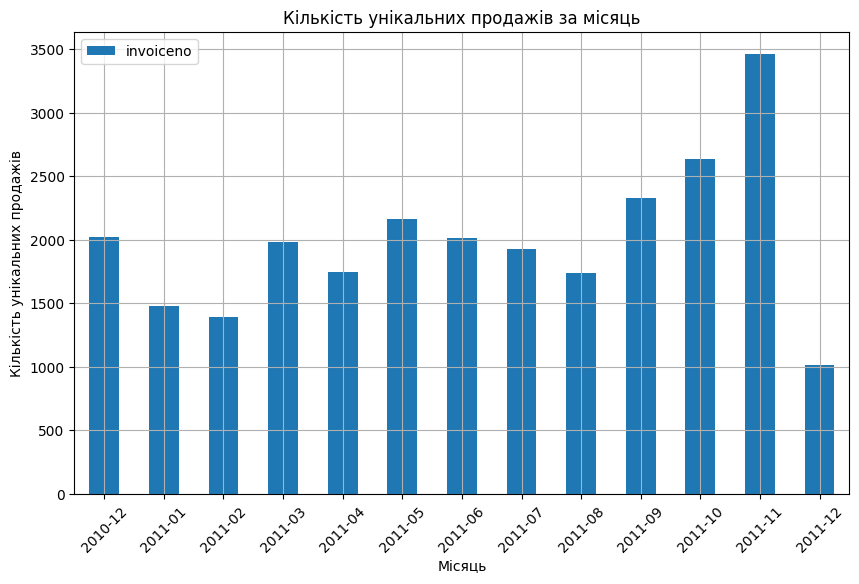

In [72]:
monthly_unique_invoices = df_new.groupby(df_new['yearmonth']).agg({'invoiceno': 'nunique'})

monthly_unique_invoices.plot(kind='bar', figsize=(10, 6))
plt.title('Кількість унікальних продажів за місяць')
plt.xlabel('Місяць')
plt.ylabel('Кількість унікальних продажів')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


Очікуваний результат:

![image-2.png](attachment:image-2.png)

18.Побудуйте стовпчастий графік кількості унікальних інвойсів для топ 10 клієнтів за цим показником.

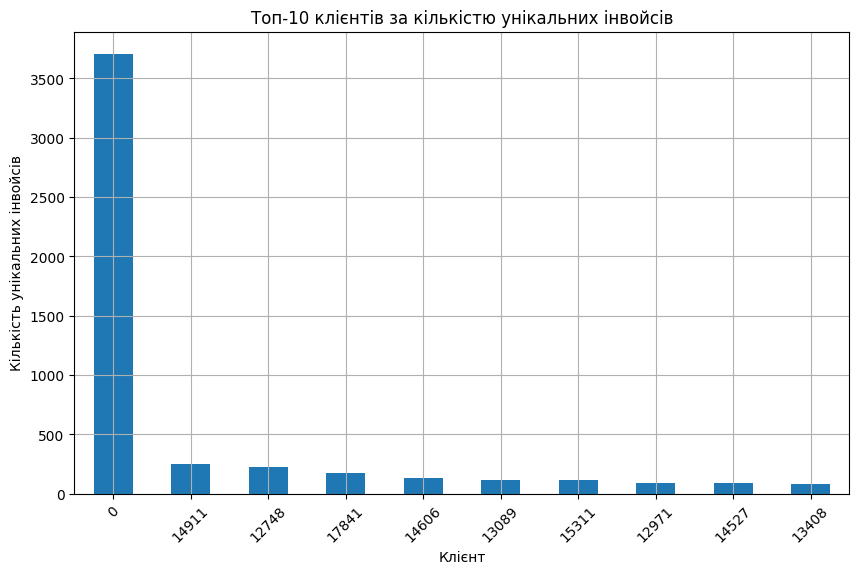

In [73]:
invoices_per_customer = df_new.groupby('custid')['invoiceno'].nunique()

top_10_customers = invoices_per_customer.nlargest(10)

top_10_customers.plot(kind='bar', figsize=(10, 6))
plt.title('Топ-10 клієнтів за кількістю унікальних інвойсів')
plt.xlabel('Клієнт')
plt.ylabel('Кількість унікальних інвойсів')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


В клієнта 0 якісь завеликі значення інвойсів, визначила також без нього:

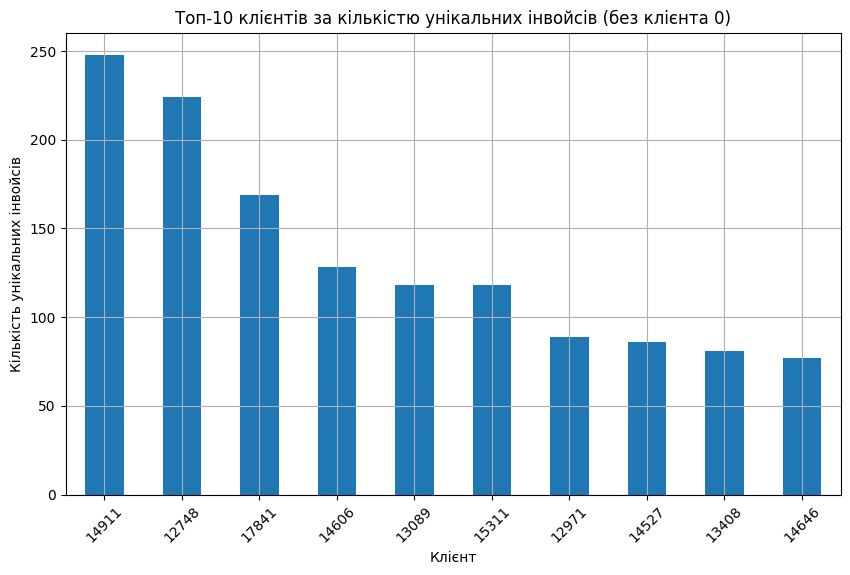

In [91]:
import matplotlib.pyplot as plt

invoices_per_customer = df_new[df_new['custid'] != '0'].groupby('custid')['invoiceno'].nunique()

top_10_customers = invoices_per_customer.nlargest(10)

top_10_customers.plot(kind='bar', figsize=(10, 6))
plt.title('Топ-10 клієнтів за кількістю унікальних інвойсів (без клієнта 0)')
plt.xlabel('Клієнт')
plt.ylabel('Кількість унікальних інвойсів')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


Очікуваний результат:

![image-2.png](attachment:image-2.png)

19.Створіть новий датафрейм, що містить сумарний `amountspent` по кожному ідентифікатору клієнта.

In [92]:
df_new = df_new[df_new['custid'] != '0']

In [93]:
total_amount_spent_per_customer = df_new.groupby('custid')['amountspent'].sum()

df_total_amount_spent_per_customer = pd.DataFrame({'custid': total_amount_spent_per_customer.index, 'total_amountspent': total_amount_spent_per_customer.values})

print(df_total_amount_spent_per_customer.head())


  custid  total_amountspent
0  12346               0.00
1  12347            4310.00
2  12348            1797.24
3  12349            1757.55
4  12350             334.40


20.Використовуючи датафрейм з попереднього пункту, виведіть, якими є 10, 25, 50, 75 і 90 персентилі сумарних витрат клієнтів за розглянутий період:

In [94]:
percentiles = [0.10, 0.25, 0.50, 0.75, 0.90]

amount_spent_percentiles = df_total_amount_spent_per_customer['total_amountspent'].quantile(percentiles)

for i, percentile in enumerate(percentiles):
    print(f'{percentile * 100} персентиль: {amount_spent_percentiles.iloc[i]}')


10.0 персентиль: 146.02200000000002
25.0 персентиль: 293.3625
50.0 персентиль: 648.075
75.0 персентиль: 1611.725
90.0 персентиль: 3505.600000000001


Очікуваний результат:

![image.png](attachment:image.png)

21.Скільки унікальних клієнтів мають сумарні витрати вищі, ніж 90-тий персентиль в попередньому завдані?

In [95]:
percentile_90 = amount_spent_percentiles.iloc[-1]

customers_above_90th_percentile = df_total_amount_spent_per_customer[df_total_amount_spent_per_customer['total_amountspent'] > percentile_90]

unique_customers_above_90th_percentile = customers_above_90th_percentile['custid'].nunique()

print(f"Кількість унікальних клієнтів з сумарними витратами вищими за 90-й персентиль: {unique_customers_above_90th_percentile}")


Кількість унікальних клієнтів з сумарними витратами вищими за 90-й персентиль: 438


22.Виведіть середню суму покупок в мережі по дням тижня. Дні тижня мають йти в звичному порядку Monday, Tuesday і т.д.

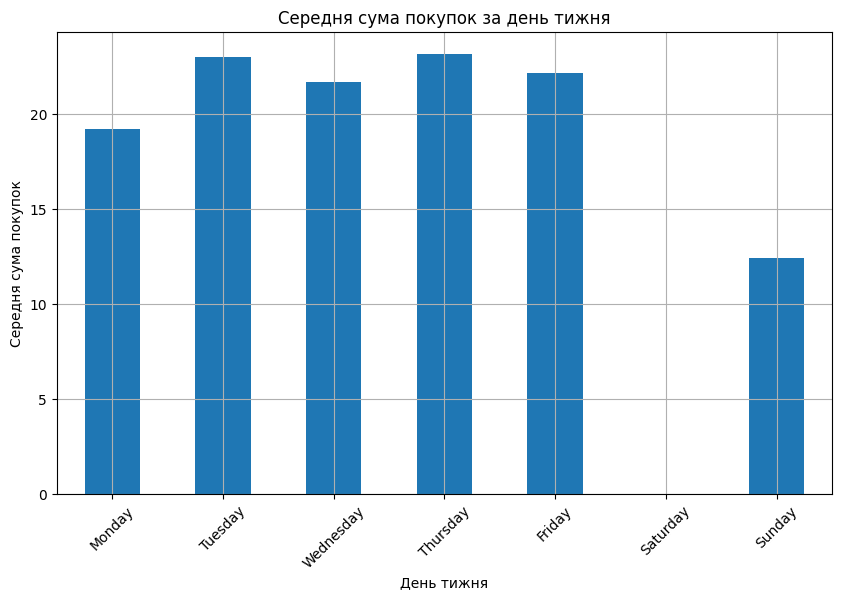

In [96]:
import matplotlib.pyplot as plt

df_new['weekday'] = df_new['invoicedate'].dt.day_name()

average_purchase_by_weekday = df_new.groupby('weekday')['amountspent'].mean()

desired_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
average_purchase_by_weekday = average_purchase_by_weekday.reindex(desired_order)

average_purchase_by_weekday.plot(kind='bar', figsize=(10, 6))

plt.title('Середня сума покупок за день тижня')
plt.xlabel('День тижня')
plt.ylabel('Середня сума покупок')
plt.xticks(rotation=45)  # Повертаємо підписи на вісі X під кутом 45 градусів
plt.grid(True)

plt.show()


Очікуваний результат:

![image.png](attachment:image.png)

## Дослідимо продажі на суму 0 умовних одиниць

23.Можна було помітити вище, що в нас є продажі на суму 0. Дослідимо їх. Створіть новий датафрейм з тільки такими продажами.

In [97]:
sales_with_zero_amount = df_new[df_new['amountspent'] == 0]

print(sales_with_zero_amount.head())


      invoiceno stockcode yearmonth  month  day  hour  \
9302     537197     22841   2010-12     12    7    14   
33576    539263     22580   2010-12     12    4    14   
40089    539722     22423   2010-12     12    2    13   
47068    540372     22090   2011-01      1    4    16   
47070    540372     22553   2011-01      1    4    16   

                        description  quantity         invoicedate  unitprice  \
9302   ROUND CAKE TIN VINTAGE GREEN         1 2010-12-05 14:02:00        0.0   
33576  ADVENT CALENDAR GINGHAM SACK         4 2010-12-16 14:36:00        0.0   
40089      REGENCY CAKESTAND 3 TIER        10 2010-12-21 13:45:00        0.0   
47068       PAPER BUNTING RETROSPOT        24 2011-01-06 16:41:00        0.0   
47070        PLASTERS IN TIN SKULLS        24 2011-01-06 16:41:00        0.0   

      custid         country  amountspent   weekday  
9302   12647         Germany          0.0    Sunday  
33576  16560  United Kingdom          0.0  Thursday  
40089  14911  

### Динаміка продажів на суму 0

24.Зобразіть у вигляді стовпчастої діаграми помісячну динаміку продажів на суму 0.

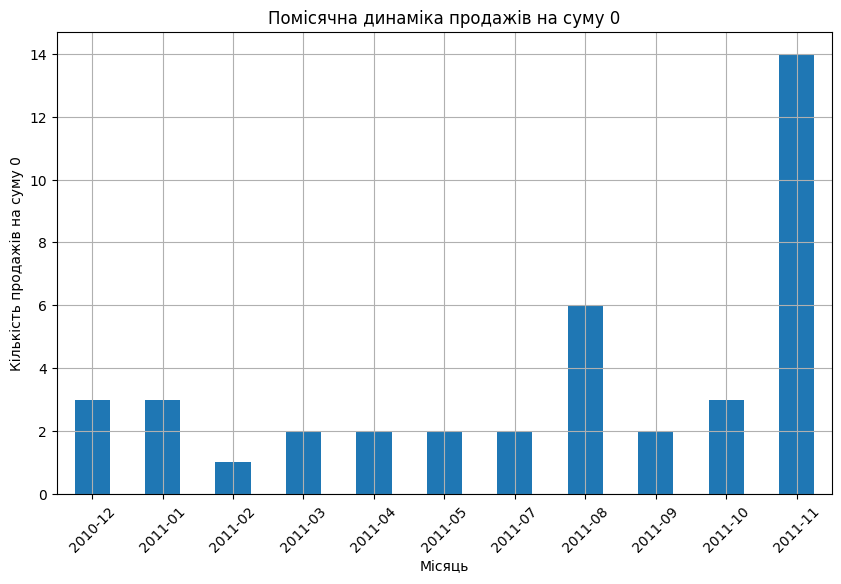

In [99]:
sales_with_zero_amount.loc[:, 'month_year'] = sales_with_zero_amount['invoicedate'].dt.to_period('M')


zero_sales_by_month = sales_with_zero_amount.groupby('month_year').size()

zero_sales_by_month.plot(kind='bar', figsize=(10, 6))

plt.title('Помісячна динаміка продажів на суму 0')
plt.xlabel('Місяць')
plt.ylabel('Кількість продажів на суму 0')
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

Очікуваний результат:

![image.png](attachment:image.png)

25.Згрупуйте дані за країнами та підрахуйте кількість унікальних інвойсів з сумою 0 для кожної країни. Виведіть у вигляді датафрейму.

In [100]:
zero_sales_by_country = df_new[df_new['amountspent'] == 0].groupby('country').agg({'invoiceno': 'nunique'})

zero_sales_by_country.rename(columns={'invoiceno': 'zero_amount_invoices'}, inplace=True)

print(zero_sales_by_country)

                zero_amount_invoices
country                             
Australia                          3
EIRE                               2
France                             1
Germany                            2
Netherlands                        1
Norway                             1
RSA                                1
Spain                              1
Switzerland                        1
United Kingdom                    21


Очікуваний результат:

![image-2.png](attachment:image-2.png)

Велике питання, чого магазин так багато порівняно роздавав безкоштовних товарів в UK, але така політика фірми :)

Якщо у вас ще є натхнення, пропоную задати до цих даних ще 3 своїх питання.

26. Розподіл сум покупок за країною

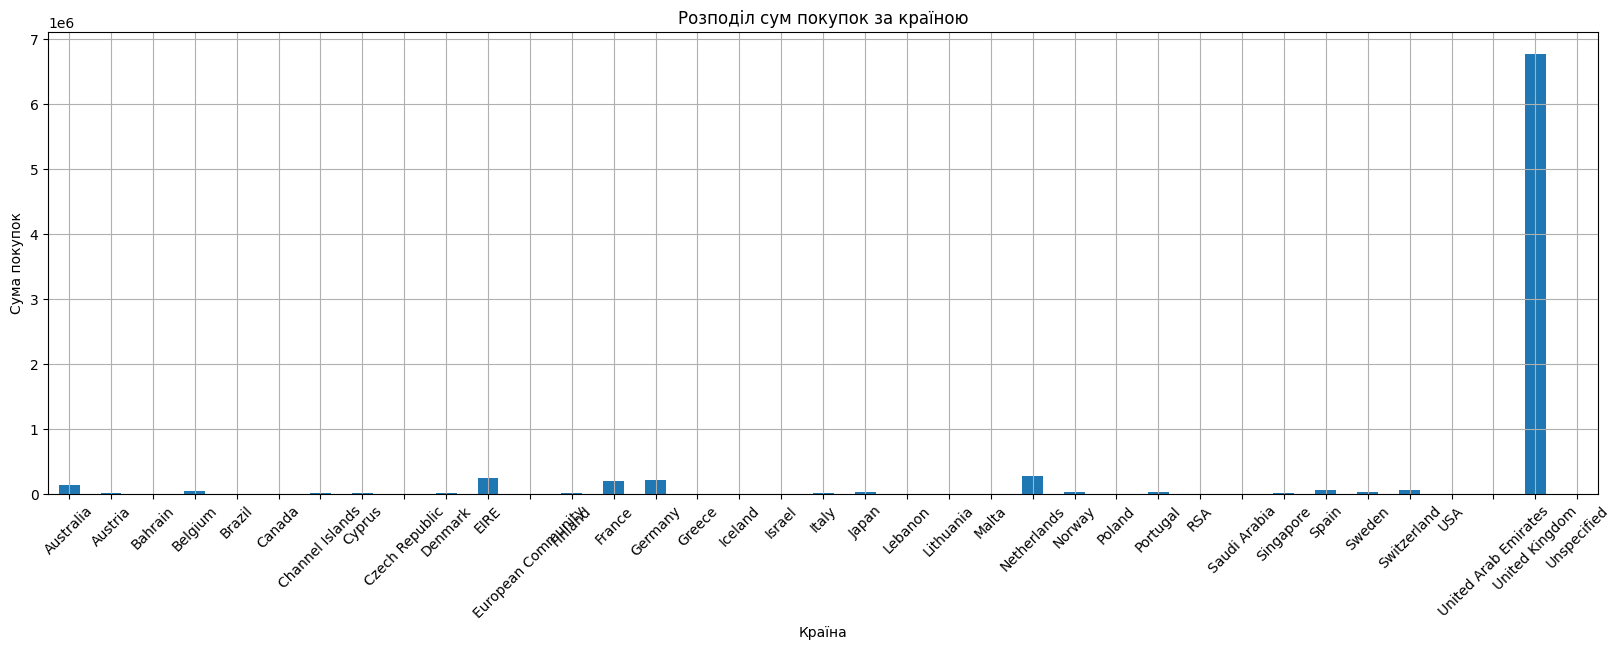

In [103]:
plt.figure(figsize=(20, 6))
total_sales_by_country.plot(kind='bar')
plt.title('Розподіл сум покупок за країною')
plt.xlabel('Країна')
plt.ylabel('Сума покупок')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


27. Помісячна динаміка продажів з сумою 0 (лінійний графік)

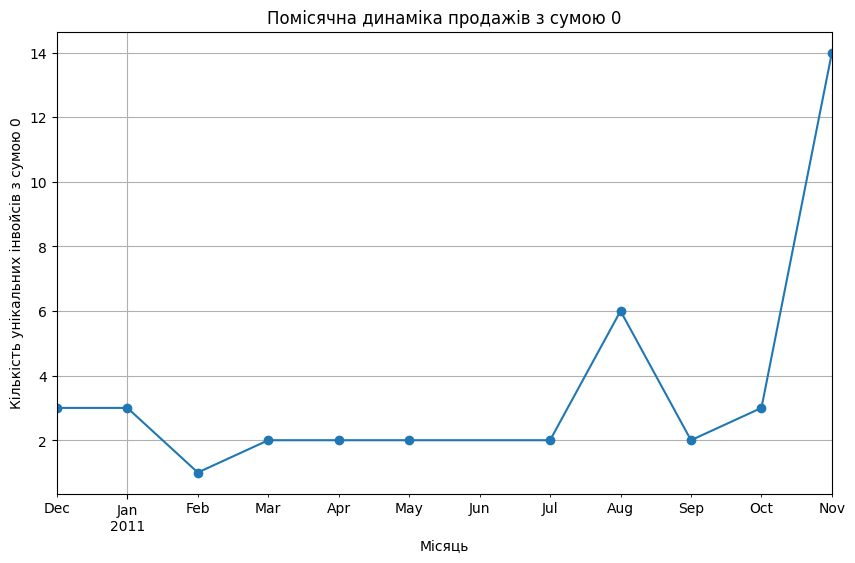

In [104]:
sales_with_zero_amount.loc[:, 'month_year'] = sales_with_zero_amount['invoicedate'].dt.to_period('M')

zero_sales_by_month = sales_with_zero_amount.groupby('month_year').size()

plt.figure(figsize=(10, 6))
zero_sales_by_month.plot(kind='line', marker='o')
plt.title('Помісячна динаміка продажів з сумою 0')
plt.xlabel('Місяць')
plt.ylabel('Кількість унікальних інвойсів з сумою 0')
plt.grid(True)
plt.show()


28. Розподіл кількості унікальних інвойсів з сумою 0 за днем тижня

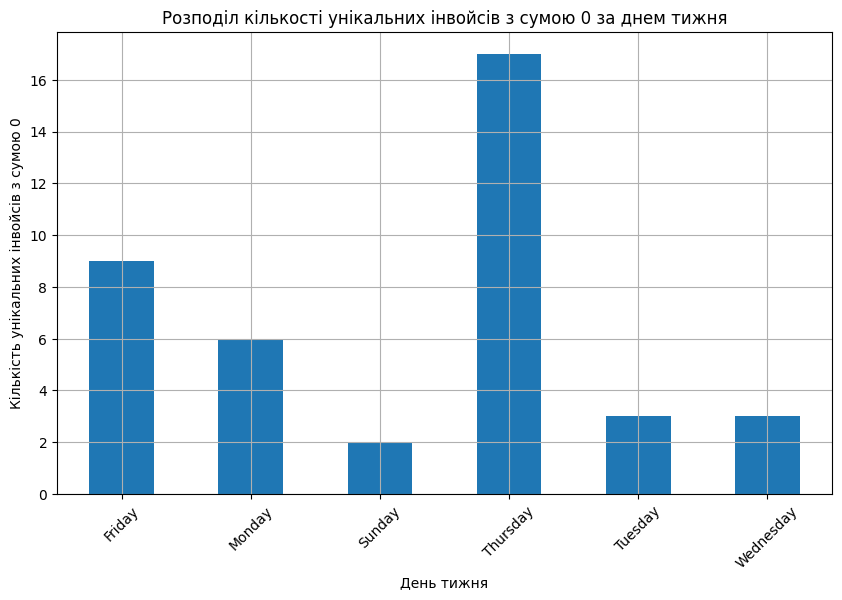

In [106]:
df_new['weekday'] = df_new['invoicedate'].dt.day_name()

zero_sales_by_weekday = df_new[df_new['amountspent'] == 0].groupby('weekday').size()

plt.figure(figsize=(10, 6))
zero_sales_by_weekday.plot(kind='bar')
plt.title('Розподіл кількості унікальних інвойсів з сумою 0 за днем тижня')
plt.xlabel('День тижня')
plt.ylabel('Кількість унікальних інвойсів з сумою 0')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()